In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("../data/processed/featured_marketing_data.csv")

In [3]:
# Feature Selection

features = ["GOOGLE_PAID_SEARCH_SPEND","GOOGLE_SHOPPING_SPEND","GOOGLE_PMAX_SPEND","GOOGLE_DISPLAY_SPEND","GOOGLE_VIDEO_SPEND",
            "META_FACEBOOK_SPEND","META_INSTAGRAM_SPEND","META_OTHER_SPEND","TIKTOK_SPEND","TOTAL_CLICKS","TOTAL_IMPRESSIONS",
            "YEAR","MONTH","QUARTER","DAY_OF_WEEK"]

In [4]:
# Target

target = "LOG_REVENUE"

In [5]:
# Train Test Split 
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
# Linear Regression 
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [7]:
print("Linear Regression")
print("R2:",r2_score(y_test,pred_lr))
print("MAE:",mean_absolute_error(y_test,pred_lr))

Linear Regression
R2: 0.3517176869268379
MAE: 1.006784651293444


In [8]:
# Random Forest 
rf = RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)

In [9]:
# Metric
print("Random Forest")
print( "R2:",r2_score(y_test,pred_rf))
print("MAE:",mean_absolute_error(y_test,pred_rf))

Random Forest
R2: 0.8640191002086584
MAE: 0.3596235533812838


In [10]:
# XGBoost
xgb = XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=6,random_state=42)
xgb.fit(X_train,y_train)
pred_xgb = xgb.predict(X_test)

In [11]:
# Metrics 
print("XGBoost")
print("R2:",r2_score(y_test,pred_xgb))
print("MAE:",mean_absolute_error(y_test,pred_xgb))

XGBoost
R2: 0.8117214187863173
MAE: 0.4915041313263772


In [12]:
# Feature Importance 
importance = pd.DataFrame({"Feature": features,"Importance": xgb.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
importance.head(15)

,Feature,Importance
10,TOTAL_IMPRESSIONS,0.338486
1,GOOGLE_SHOPPING_SPEND,0.228721
5,META_FACEBOOK_SPEND,0.107632
2,GOOGLE_PMAX_SPEND,0.100668
0,GOOGLE_PAID_SEARCH_SPEND,0.080763
9,TOTAL_CLICKS,0.034724
11,YEAR,0.025384
6,META_INSTAGRAM_SPEND,0.021298
3,GOOGLE_DISPLAY_SPEND,0.020404
12,MONTH,0.011115


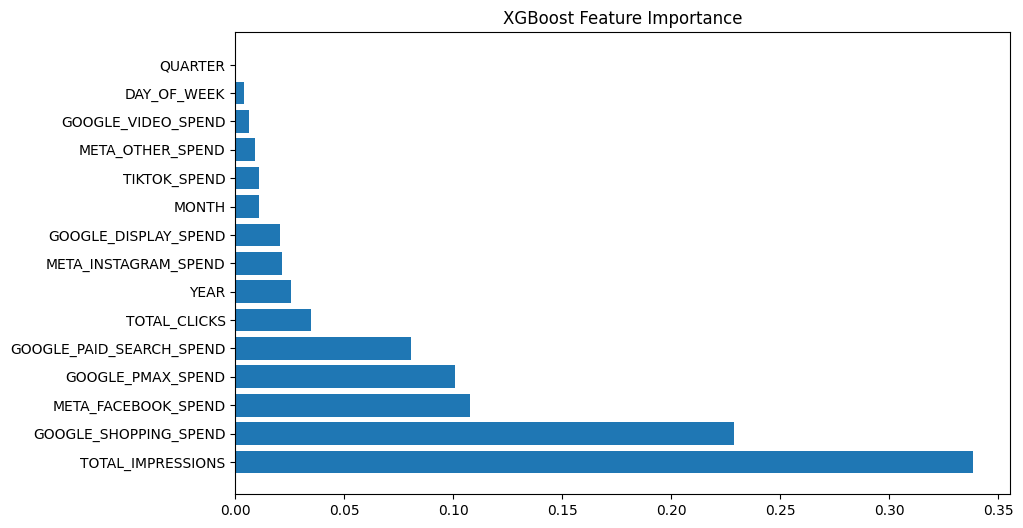

In [13]:
# Plot 
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"][:15],importance["Importance"][:15])
plt.title("XGBoost Feature Importance")
plt.show()

In [14]:
model_results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest","XGBoost"],
    "R2":[0.3517,0.8640,0.8117],
    "MAE":[1.0068,0.3596,0.4915]
})
model_results

,Model,R2,MAE
0,Linear Regression,0.3517,1.0068
1,Random Forest,0.8640,0.3596
2,XGBoost,0.8117,0.4915


In [15]:
model_results.to_csv("../results/model_comparison.csv",index=False)

In [16]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
10,TOTAL_IMPRESSIONS,0.339264
1,GOOGLE_SHOPPING_SPEND,0.211103
5,META_FACEBOOK_SPEND,0.127395
0,GOOGLE_PAID_SEARCH_SPEND,0.103164
2,GOOGLE_PMAX_SPEND,0.072847
9,TOTAL_CLICKS,0.062068
11,YEAR,0.021685
12,MONTH,0.019713
6,META_INSTAGRAM_SPEND,0.012480
14,DAY_OF_WEEK,0.010638


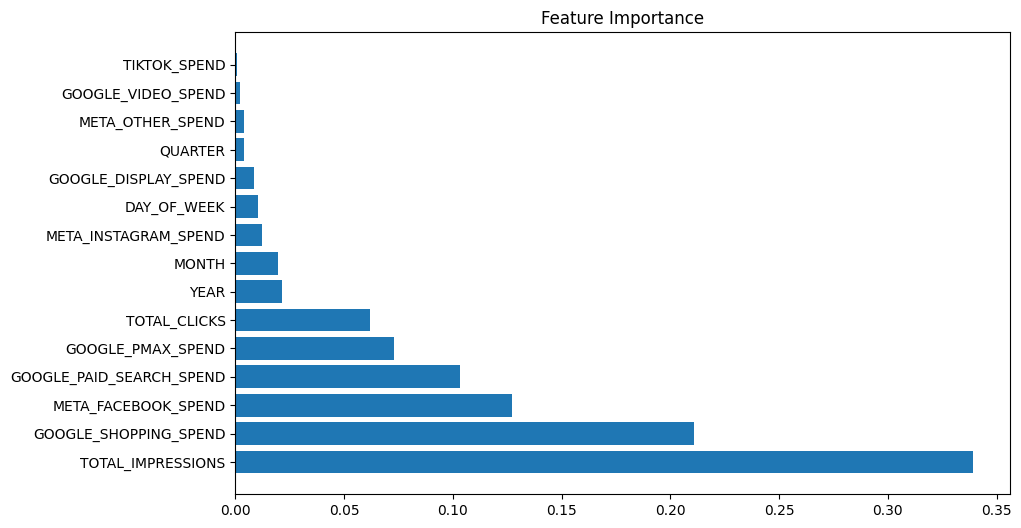

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(
    importance_df["Feature"][:15],
    importance_df["Importance"][:15]
)
plt.title("Feature Importance")
plt.show()

In [18]:
importance_df.to_csv("../results/feature_importance.csv",index=False)